In [122]:
import pandas as pd
import numpy as np

import os
import re
from collections import Counter

from pathlib import Path
import matplotlib.pyplot as plt
from kiwipiepy import Kiwi

In [123]:
plt.rcParams['font.family'] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [124]:
def read_csv_safe(file_path):
    encodings = ["utf-8-sig", "utf-8", "cp949", "euc-kr"]

    for enc in encodings:
        try:
            return pd.read_csv(file_path, encoding=enc)
        except UnicodeDecodeError:
            continue

    raise ValueError(f"인코딩 실패: {file_path}")

In [125]:
def load_yearly_same_name(filename, years, base_dir="data"):
    dfs = []

    for year in years:
        file_path = Path(base_dir) / str(year) / filename

        if not file_path.exists():
            print(f"파일 없음: {file_path}")
            continue

        temp = read_csv_safe(file_path)
        temp["season"] = year

        dfs.append(temp)
        print(f"로드 완료: {file_path}, shape={temp.shape}")

    if len(dfs) == 0:
        raise FileNotFoundError(f"{filename} 파일을 하나도 찾지 못했습니다.")

    return pd.concat(dfs, ignore_index=True)

In [126]:
years = [2022, 2023, 2024, 2025]

base_dir = r"C:\Users\Admin\Documents\GitHub\Ml_Baseball\data"

In [127]:
team_rank = load_yearly_same_name("팀_순위.csv", years, base_dir)
team_daily_rank = load_yearly_same_name("팀_일자별순위.csv", years, base_dir)

team_hitter = load_yearly_same_name("팀_타자_기본기록.csv", years, base_dir)
team_pitcher = load_yearly_same_name("팀_투수_기본기록.csv", years, base_dir)
team_defense = load_yearly_same_name("팀_수비_기본기록.csv", years, base_dir)
team_runner = load_yearly_same_name("팀_주루_기본기록.csv", years, base_dir)

hitter_basic = load_yearly_same_name("타자_기본기록.csv", years, base_dir)
hitter_detail = load_yearly_same_name("타자_세부기록.csv", years, base_dir)

pitcher_basic = load_yearly_same_name("투수_기본기록.csv", years, base_dir)
pitcher_detail = load_yearly_same_name("투수_세부기록.csv", years, base_dir)

defense_basic = load_yearly_same_name("수비_기본기록.csv", years, base_dir)
runner_basic = load_yearly_same_name("주루_기본기록.csv", years, base_dir)

로드 완료: C:\Users\Admin\Documents\GitHub\Ml_Baseball\data\2022\팀_순위.csv, shape=(10, 13)
로드 완료: C:\Users\Admin\Documents\GitHub\Ml_Baseball\data\2023\팀_순위.csv, shape=(10, 13)
로드 완료: C:\Users\Admin\Documents\GitHub\Ml_Baseball\data\2024\팀_순위.csv, shape=(10, 13)
로드 완료: C:\Users\Admin\Documents\GitHub\Ml_Baseball\data\2025\팀_순위.csv, shape=(10, 13)
로드 완료: C:\Users\Admin\Documents\GitHub\Ml_Baseball\data\2022\팀_일자별순위.csv, shape=(1590, 14)
로드 완료: C:\Users\Admin\Documents\GitHub\Ml_Baseball\data\2023\팀_일자별순위.csv, shape=(1670, 14)
로드 완료: C:\Users\Admin\Documents\GitHub\Ml_Baseball\data\2024\팀_일자별순위.csv, shape=(1630, 14)
로드 완료: C:\Users\Admin\Documents\GitHub\Ml_Baseball\data\2025\팀_일자별순위.csv, shape=(1630, 14)
로드 완료: C:\Users\Admin\Documents\GitHub\Ml_Baseball\data\2022\팀_타자_기본기록.csv, shape=(10, 16)
로드 완료: C:\Users\Admin\Documents\GitHub\Ml_Baseball\data\2023\팀_타자_기본기록.csv, shape=(10, 16)
로드 완료: C:\Users\Admin\Documents\GitHub\Ml_Baseball\data\2024\팀_타자_기본기록.csv, shape=(10, 16)
로드 완료: C:\Users\Adm

In [128]:
print(team_hitter.shape)
display(team_hitter.head())

(40, 16)


,순위,팀명,AVG,G,PA,AB,R,H,2B,3B,HR,TB,RBI,SAC,SF,season
0,1,KIA,0.272,144,5703,5000,720,1361,250,19,113,1988,677,61,36,2022
1,2,삼성,0.270,144,5647,5023,663,1358,241,19,103,1946,627,83,41,2022
2,3,LG,0.269,144,5627,4927,715,1325,208,33,118,1953,674,49,46,2022
3,4,롯데,0.267,144,5534,4948,605,1320,227,16,106,1897,570,73,42,2022
4,5,NC,0.257,144,5585,4899,646,1260,230,15,105,1835,613,50,47,2022


In [129]:
team_daily_rank = team_daily_rank.rename(columns={
    "날짜": "date",
    "일자": "date",
    "기준일자": "date",
    "경기일자": "date",

    "팀명": "team",
    "팀": "team",

    "순위": "rank",
    "경기": "games",
    "승": "wins",
    "패": "losses",
    "무": "draws",
    "승률": "win_rate",
    "게임차": "games_behind",
    "최근10경기": "recent_10",
    "최근10": "recent_10",
    "연속": "streak",
    "홈": "home_record",
    "방문": "away_record",
    "원정": "away_record"
})

team_rank = team_rank.rename(columns={
    "년도": "season",
    "연도": "season",
    "팀명": "team",
    "팀": "team",
    "순위": "final_rank",
    "최종순위": "final_rank"
})

In [130]:
team_hitter = team_hitter.rename(columns={
    "팀명": "team",
    "팀": "team",
    "AVG": "team_avg",
    "R": "team_runs",
    "H": "team_hits",
    "HR": "team_hr",
    "RBI": "team_rbi",
    "OBP": "team_obp",
    "SLG": "team_slg",
    "OPS": "team_ops"
})

team_pitcher = team_pitcher.rename(columns={
    "팀명": "team",
    "팀": "team",
    "ERA": "team_era",
    "WHIP": "team_whip",
    "R": "team_runs_allowed",
    "ER": "team_er",
    "HR": "team_hr_allowed",
    "BB": "team_bb_allowed",
    "SO": "team_so_pitcher",
    "IP": "team_ip"
})

team_defense = team_defense.rename(columns={
    "팀명": "team",
    "팀": "team",
    "E": "team_errors",
    "FPCT": "team_fpct",
    "DP": "team_dp"
})

team_runner = team_runner.rename(columns={
    "팀명": "team",
    "팀": "team",
    "SB": "team_sb",
    "CS": "team_cs",
    "SB%": "team_sb_rate"
})

In [131]:
hitter_basic = hitter_basic.rename(columns={
    "선수명": "player_name",
    "팀명": "team",
    "팀": "team",
    "순위": "rank",
    "AVG": "hitter_avg",
    "G": "hitter_g",
    "PA": "hitter_pa",
    "AB": "hitter_ab",
    "R": "hitter_runs",
    "H": "hitter_hits",
    "2B": "hitter_2b",
    "3B": "hitter_3b",
    "HR": "hitter_hr",
    "TB": "hitter_tb",
    "RBI": "hitter_rbi",
    "SAC": "hitter_sac",
    "SF": "hitter_sf"
})

hitter_detail = hitter_detail.rename(columns={
    "선수명": "player_name",
    "팀명": "team",
    "팀": "team",
    "순위": "rank",
    "AVG": "hitter_avg_detail",
    "XBH": "hitter_xbh",
    "GO": "hitter_go",
    "AO": "hitter_ao",
    "GO/AO": "hitter_go_ao",
    "GW RBI": "hitter_gw_rbi",
    "BB/K": "hitter_bb_k",
    "P/PA": "hitter_p_pa",
    "ISOP": "hitter_isop",
    "XR": "hitter_xr",
    "GPA": "hitter_gpa"
})

pitcher_basic = pitcher_basic.rename(columns={
    "선수명": "player_name",
    "팀명": "team",
    "팀": "team",
    "순위": "rank",
    "ERA": "pitcher_era",
    "G": "pitcher_g",
    "W": "pitcher_w",
    "L": "pitcher_l",
    "SV": "pitcher_sv",
    "HLD": "pitcher_hld",
    "WPCT": "pitcher_wpct",
    "IP": "pitcher_ip",
    "H": "pitcher_h_allowed",
    "HR": "pitcher_hr_allowed",
    "BB": "pitcher_bb_allowed",
    "HBP": "pitcher_hbp",
    "SO": "pitcher_so",
    "R": "pitcher_runs_allowed",
    "ER": "pitcher_er",
    "WHIP": "pitcher_whip"
})

pitcher_detail = pitcher_detail.rename(columns={
    "선수명": "player_name",
    "팀명": "team",
    "팀": "team",
    "순위": "rank",
    "ERA": "pitcher_era_detail",
    "GS": "pitcher_gs",
    "Wgs": "pitcher_wgs",
    "Wgr": "pitcher_wgr",
    "GF": "pitcher_gf",
    "SVO": "pitcher_svo",
    "TS": "pitcher_ts",
    "GDP": "pitcher_gdp",
    "GO": "pitcher_go",
    "AO": "pitcher_ao",
    "GO/AO": "pitcher_go_ao"
})

In [132]:
team_hitter_use = team_hitter[[
    "season", "team",
    "team_avg",
    "team_runs",
    "team_hits",
    "team_hr",
    "team_rbi"
]].copy()

team_pitcher_use = team_pitcher[[
    "season", "team",
    "team_era",
    "team_ip",
    "team_hr_allowed",
    "team_bb_allowed",
    "team_so_pitcher",
    "team_runs_allowed",
    "team_er",
    "team_whip"
]].copy()

team_defense_use = team_defense[[
    "season", "team",
    "team_errors",
    "team_dp",
    "team_fpct"
]].copy()

team_runner_use = team_runner[[
    "season", "team",
    "team_sb",
    "team_cs",
    "team_sb_rate"
]].copy()

In [133]:
def clean_numeric_value(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip()

    if x in ["-", "", "nan", "None"]:
        return np.nan

    x = x.replace(",", "")
    x = x.replace("%", "")

    try:
        return float(x)
    except:
        return np.nan


def convert_numeric_except(df, exclude_cols):
    df = df.copy()

    for col in df.columns:
        if col not in exclude_cols:
            df[col] = df[col].apply(clean_numeric_value)

    return df

In [134]:
team_daily_rank = convert_numeric_except(
    team_daily_rank,
    exclude_cols=["date", "team", "recent_10", "streak", "home_record", "away_record"]
)

team_rank = convert_numeric_except(
    team_rank,
    exclude_cols=["team"]
)

team_hitter = convert_numeric_except(team_hitter, exclude_cols=["team"])
team_pitcher = convert_numeric_except(team_pitcher, exclude_cols=["team"])
team_defense = convert_numeric_except(team_defense, exclude_cols=["team"])
team_runner = convert_numeric_except(team_runner, exclude_cols=["team"])

hitter_basic = convert_numeric_except(hitter_basic, exclude_cols=["player_name", "team"])
hitter_detail = convert_numeric_except(hitter_detail, exclude_cols=["player_name", "team"])

pitcher_basic = convert_numeric_except(pitcher_basic, exclude_cols=["player_name", "team"])
pitcher_detail = convert_numeric_except(pitcher_detail, exclude_cols=["player_name", "team"])

In [135]:
team_daily_rank["date"] = pd.to_datetime(team_daily_rank["date"])
team_daily_rank["month"] = team_daily_rank["date"].dt.month

In [136]:
def parse_recent10(text):
    if pd.isna(text):
        return pd.Series([np.nan, np.nan, np.nan, np.nan])

    text = str(text)

    win = re.search(r"(\d+)승", text)
    draw = re.search(r"(\d+)무", text)
    loss = re.search(r"(\d+)패", text)

    wins = int(win.group(1)) if win else 0
    draws = int(draw.group(1)) if draw else 0
    losses = int(loss.group(1)) if loss else 0

    total = wins + draws + losses
    win_rate = wins / total if total > 0 else np.nan

    return pd.Series([wins, draws, losses, win_rate])


team_daily_rank[[
    "recent10_wins",
    "recent10_draws",
    "recent10_losses",
    "recent10_win_rate"
]] = team_daily_rank["recent_10"].apply(parse_recent10)

In [137]:
# 홈 원정 기록 파싱
def parse_record(text):
    if pd.isna(text):
        return pd.Series([np.nan, np.nan, np.nan, np.nan])

    nums = re.findall(r"\d+", str(text))

    if len(nums) < 3:
        return pd.Series([np.nan, np.nan, np.nan, np.nan])

    wins = int(nums[0])
    draws = int(nums[1])
    losses = int(nums[2])

    total = wins + draws + losses
    win_rate = wins / total if total > 0 else np.nan

    return pd.Series([wins, draws, losses, win_rate])


team_daily_rank[[
    "home_wins",
    "home_draws",
    "home_losses",
    "home_win_rate"
]] = team_daily_rank["home_record"].apply(parse_record)

team_daily_rank[[
    "away_wins",
    "away_draws",
    "away_losses",
    "away_win_rate"
]] = team_daily_rank["away_record"].apply(parse_record)

In [138]:
 # 시즌 진행률 생성
team_daily_rank["games_played_ratio"] = team_daily_rank["games"] / 144

In [139]:
# postseason 라벨 생성
team_rank["postseason"] = (team_rank["final_rank"] <= 5).astype(int)

In [140]:
team_daily_rank = team_daily_rank.merge(
    team_rank[["season", "team", "final_rank", "postseason"]],
    on=["season", "team"],
    how="left"
)

team_daily_rank[["season", "date", "team", "rank", "final_rank", "postseason"]].head()

,season,date,team,rank,final_rank,postseason
0,2022.0,1970-01-01 00:00:00.020220402,KT,1.0,4.0,1
1,2022.0,1970-01-01 00:00:00.020220402,두산,1.0,9.0,0
2,2022.0,1970-01-01 00:00:00.020220402,LG,1.0,3.0,1
3,2022.0,1970-01-01 00:00:00.020220402,SSG,1.0,1.0,1
4,2022.0,1970-01-01 00:00:00.020220402,롯데,1.0,8.0,0


In [141]:
team_daily_rank.columns

Index(['date', 'rank', 'team', 'games', 'wins', 'losses', 'draws', 'win_rate',
       'games_behind', 'recent_10', 'streak', 'home_record', 'away_record',
       'season', 'month', 'recent10_wins', 'recent10_draws', 'recent10_losses',
       'recent10_win_rate', 'home_wins', 'home_draws', 'home_losses',
       'home_win_rate', 'away_wins', 'away_draws', 'away_losses',
       'away_win_rate', 'games_played_ratio', 'final_rank', 'postseason'],
      dtype='str')

In [142]:
# 팀 기록 하나로 합치기
team_stats = (
    team_hitter_use
    .merge(team_pitcher_use, on=["season", "team"], how="outer")
    .merge(team_defense_use, on=["season", "team"], how="outer")
    .merge(team_runner_use, on=["season", "team"], how="outer")
)

print(team_stats.shape)
display(team_stats.head())

(40, 21)


,season,team,team_avg,team_runs,team_hits,team_hr,team_rbi,team_era,team_ip,team_hr_allowed,...,team_so_pitcher,team_runs_allowed,team_er,team_whip,team_errors,team_dp,team_fpct,team_sb,team_cs,team_sb_rate
0,2022,KIA,0.272,720,1361,113,677,4.20,1279 2/3,120,...,1042,679,597,1.42,107,111,0.980,103,34,75.2
1,2022,KT,0.254,631,1237,119,588,3.51,1287 1/3,92,...,1074,562,502,1.25,97,132,0.982,89,34,72.4
2,2022,LG,0.269,715,1325,118,674,3.33,1288,94,...,1031,521,476,1.27,89,139,0.983,102,46,68.9
3,2022,NC,0.257,646,1260,105,613,3.90,1286 2/3,111,...,1168,642,557,1.36,127,115,0.976,100,39,71.9
4,2022,SSG,0.254,720,1245,138,682,3.87,1301 1/3,130,...,1023,622,560,1.29,109,138,0.980,98,39,71.5


In [143]:
# 팀 기록 전년도 변수로 바꾸기
prev_team_stats = team_stats.copy()

prev_team_stats["season"] = prev_team_stats["season"] + 1

prev_cols = [
    col for col in prev_team_stats.columns
    if col not in ["season", "team"]
]

prev_team_stats = prev_team_stats.rename(
    columns={col: f"prev_{col}" for col in prev_cols}
)

prev_team_stats.head()

,season,team,prev_team_avg,prev_team_runs,prev_team_hits,prev_team_hr,prev_team_rbi,prev_team_era,prev_team_ip,prev_team_hr_allowed,...,prev_team_so_pitcher,prev_team_runs_allowed,prev_team_er,prev_team_whip,prev_team_errors,prev_team_dp,prev_team_fpct,prev_team_sb,prev_team_cs,prev_team_sb_rate
0,2023,KIA,0.272,720,1361,113,677,4.20,1279 2/3,120,...,1042,679,597,1.42,107,111,0.980,103,34,75.2
1,2023,KT,0.254,631,1237,119,588,3.51,1287 1/3,92,...,1074,562,502,1.25,97,132,0.982,89,34,72.4
2,2023,LG,0.269,715,1325,118,674,3.33,1288,94,...,1031,521,476,1.27,89,139,0.983,102,46,68.9
3,2023,NC,0.257,646,1260,105,613,3.90,1286 2/3,111,...,1168,642,557,1.36,127,115,0.976,100,39,71.9
4,2023,SSG,0.254,720,1245,138,682,3.87,1301 1/3,130,...,1023,622,560,1.29,109,138,0.980,98,39,71.5


In [145]:
# 선수 기본 + 세부 합치기

hitter = hitter_basic.merge(
    hitter_detail,
    on=["season", "player_name", "team"],
    how="left",
    suffixes=("_basic", "_detail")
)

pitcher = pitcher_basic.merge(
    pitcher_detail,
    on=["season", "player_name", "team"],
    how="left",
    suffixes=("_basic", "_detail")
)

print(hitter.shape)
print(pitcher.shape)

(202, 29)
(81, 32)


In [146]:
# 선수 기록 팀 단위 요약
# 타자
def summarize_hitter_team(hitter):
    rows = []

    for (season, team), group in hitter.groupby(["season", "team"]):
        row = {
            "season": season,
            "team": team
        }

        # 결측치 때문에 안전하게 처리
        row["top5_hitter_hr_sum"] = group.nlargest(5, "hitter_hr")["hitter_hr"].sum()
        row["top5_hitter_rbi_sum"] = group.nlargest(5, "hitter_rbi")["hitter_rbi"].sum()
        row["top5_hitter_hits_sum"] = group.nlargest(5, "hitter_hits")["hitter_hits"].sum()
        row["top5_hitter_tb_sum"] = group.nlargest(5, "hitter_tb")["hitter_tb"].sum()

        if "hitter_gpa" in group.columns:
            row["top5_hitter_gpa_avg"] = group.nlargest(5, "hitter_gpa")["hitter_gpa"].mean()

        if "hitter_isop" in group.columns:
            row["top5_hitter_isop_avg"] = group.nlargest(5, "hitter_isop")["hitter_isop"].mean()

        if "hitter_xr" in group.columns:
            row["top5_hitter_xr_sum"] = group.nlargest(5, "hitter_xr")["hitter_xr"].sum()

        rows.append(row)

    return pd.DataFrame(rows)


hitter_team_summary = summarize_hitter_team(hitter)
hitter_team_summary.head()

,season,team,top5_hitter_hr_sum,top5_hitter_rbi_sum,top5_hitter_hits_sum,top5_hitter_tb_sum,top5_hitter_gpa_avg,top5_hitter_isop_avg,top5_hitter_xr_sum
0,2022.0,KIA,84.0,397.0,741.0,1099.0,0.2750,0.1734,401.6
1,2022.0,KT,58.0,296.0,628.0,916.0,0.2534,0.1258,326.0
2,2022.0,LG,77.0,383.0,714.0,1077.0,0.2766,0.1518,395.6
3,2022.0,NC,65.0,363.0,672.0,1008.0,0.2780,0.1502,371.3
4,2022.0,SSG,75.0,362.0,657.0,1032.0,0.2796,0.1648,402.3


In [147]:
# 투수 요약
def summarize_pitcher_team(pitcher):
    rows = []

    for (season, team), group in pitcher.groupby(["season", "team"]):
        row = {
            "season": season,
            "team": team
        }

        # 이닝 너무 적은 투수 제외
        qualified = group[group["pitcher_ip"] >= 20].copy()

        if len(qualified) == 0:
            qualified = group.copy()

        row["top5_pitcher_era_avg"] = qualified.nsmallest(5, "pitcher_era")["pitcher_era"].mean()
        row["top5_pitcher_whip_avg"] = qualified.nsmallest(5, "pitcher_whip")["pitcher_whip"].mean()
        row["top5_pitcher_ip_sum"] = group.nlargest(5, "pitcher_ip")["pitcher_ip"].sum()
        row["top5_pitcher_so_sum"] = group.nlargest(5, "pitcher_so")["pitcher_so"].sum()
        row["top5_pitcher_bb_allowed_sum"] = group.nlargest(5, "pitcher_bb_allowed")["pitcher_bb_allowed"].sum()
        row["top5_pitcher_hr_allowed_sum"] = group.nlargest(5, "pitcher_hr_allowed")["pitcher_hr_allowed"].sum()

        rows.append(row)

    return pd.DataFrame(rows)


pitcher_team_summary = summarize_pitcher_team(pitcher)
pitcher_team_summary.head()

,season,team,top5_pitcher_era_avg,top5_pitcher_whip_avg,top5_pitcher_ip_sum,top5_pitcher_so_sum,top5_pitcher_bb_allowed_sum,top5_pitcher_hr_allowed_sum
0,2022.0,KIA,3.860,1.310,154.0,302.0,124.0,32.0
1,2022.0,KT,4.530,1.510,163.0,396.0,110.0,29.0
2,2022.0,LG,2.390,1.010,162.0,302.0,73.0,23.0
3,2022.0,NC,2.970,1.130,0.0,194.0,34.0,14.0
4,2022.0,SSG,3.595,1.225,328.0,435.0,137.0,44.0


In [148]:
# 선수 요약 합치기
player_team_summary = hitter_team_summary.merge(
    pitcher_team_summary,
    on=["season", "team"],
    how="outer"
)

player_team_summary.head()

,season,team,top5_hitter_hr_sum,top5_hitter_rbi_sum,top5_hitter_hits_sum,top5_hitter_tb_sum,top5_hitter_gpa_avg,top5_hitter_isop_avg,top5_hitter_xr_sum,top5_pitcher_era_avg,top5_pitcher_whip_avg,top5_pitcher_ip_sum,top5_pitcher_so_sum,top5_pitcher_bb_allowed_sum,top5_pitcher_hr_allowed_sum
0,2022.0,KIA,84.0,397.0,741.0,1099.0,0.2750,0.1734,401.6,3.860,1.310,154.0,302.0,124.0,32.0
1,2022.0,KT,58.0,296.0,628.0,916.0,0.2534,0.1258,326.0,4.530,1.510,163.0,396.0,110.0,29.0
2,2022.0,LG,77.0,383.0,714.0,1077.0,0.2766,0.1518,395.6,2.390,1.010,162.0,302.0,73.0,23.0
3,2022.0,NC,65.0,363.0,672.0,1008.0,0.2780,0.1502,371.3,2.970,1.130,0.0,194.0,34.0,14.0
4,2022.0,SSG,75.0,362.0,657.0,1032.0,0.2796,0.1648,402.3,3.595,1.225,328.0,435.0,137.0,44.0


In [149]:
# 선수 요약 전년도 변수로 바꾸기
prev_player_summary = player_team_summary.copy()

prev_player_summary["season"] = prev_player_summary["season"] + 1

prev_player_cols = [
    col for col in prev_player_summary.columns
    if col not in ["season", "team"]
]

prev_player_summary = prev_player_summary.rename(
    columns={col: f"prev_{col}" for col in prev_player_cols}
)

prev_player_summary.head()

,season,team,prev_top5_hitter_hr_sum,prev_top5_hitter_rbi_sum,prev_top5_hitter_hits_sum,prev_top5_hitter_tb_sum,prev_top5_hitter_gpa_avg,prev_top5_hitter_isop_avg,prev_top5_hitter_xr_sum,prev_top5_pitcher_era_avg,prev_top5_pitcher_whip_avg,prev_top5_pitcher_ip_sum,prev_top5_pitcher_so_sum,prev_top5_pitcher_bb_allowed_sum,prev_top5_pitcher_hr_allowed_sum
0,2023.0,KIA,84.0,397.0,741.0,1099.0,0.2750,0.1734,401.6,3.860,1.310,154.0,302.0,124.0,32.0
1,2023.0,KT,58.0,296.0,628.0,916.0,0.2534,0.1258,326.0,4.530,1.510,163.0,396.0,110.0,29.0
2,2023.0,LG,77.0,383.0,714.0,1077.0,0.2766,0.1518,395.6,2.390,1.010,162.0,302.0,73.0,23.0
3,2023.0,NC,65.0,363.0,672.0,1008.0,0.2780,0.1502,371.3,2.970,1.130,0.0,194.0,34.0,14.0
4,2023.0,SSG,75.0,362.0,657.0,1032.0,0.2796,0.1648,402.3,3.595,1.225,328.0,435.0,137.0,44.0


In [151]:
# 최종 model_df
model_df = team_daily_rank.merge(
    prev_team_stats,
    on=["season", "team"],
    how="left"
)

model_df = model_df.merge(
    prev_player_summary,
    on=["season", "team"],
    how="left"
)

print(model_df.shape)
model_df.head()

(6520, 62)


,date,rank,team,games,wins,losses,draws,win_rate,games_behind,recent_10,...,prev_top5_hitter_tb_sum,prev_top5_hitter_gpa_avg,prev_top5_hitter_isop_avg,prev_top5_hitter_xr_sum,prev_top5_pitcher_era_avg,prev_top5_pitcher_whip_avg,prev_top5_pitcher_ip_sum,prev_top5_pitcher_so_sum,prev_top5_pitcher_bb_allowed_sum,prev_top5_pitcher_hr_allowed_sum
0,1970-01-01 00:00:00.020220402,1.0,KT,1.0,1.0,0.0,0.0,1.0,0.0,1승0무0패,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1970-01-01 00:00:00.020220402,1.0,두산,1.0,1.0,0.0,0.0,1.0,0.0,1승0무0패,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1970-01-01 00:00:00.020220402,1.0,LG,1.0,1.0,0.0,0.0,1.0,0.0,1승0무0패,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1970-01-01 00:00:00.020220402,1.0,SSG,1.0,1.0,0.0,0.0,1.0,0.0,1승0무0패,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1970-01-01 00:00:00.020220402,1.0,롯데,1.0,1.0,0.0,0.0,1.0,0.0,1승0무0패,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [152]:
missing = model_df.isnull().sum().sort_values(ascending=False)
missing[missing > 0].head(30)

prev_top5_pitcher_so_sum      1590
prev_top5_pitcher_ip_sum      1590
prev_top5_pitcher_whip_avg    1590
prev_top5_pitcher_era_avg     1590
prev_top5_hitter_xr_sum       1590
prev_top5_hitter_isop_avg     1590
prev_top5_hitter_gpa_avg      1590
prev_top5_hitter_tb_sum       1590
prev_top5_hitter_hits_sum     1590
prev_top5_hitter_rbi_sum      1590
prev_top5_hitter_hr_sum       1590
prev_team_sb_rate             1590
prev_team_cs                  1590
prev_team_sb                  1590
prev_team_fpct                1590
prev_team_dp                  1590
prev_team_errors              1590
prev_team_whip                1590
prev_team_er                  1590
prev_team_runs_allowed        1590
prev_team_so_pitcher          1590
prev_team_bb_allowed          1590
prev_team_hr_allowed          1590
prev_team_ip                  1590
prev_team_era                 1590
prev_team_rbi                 1590
prev_team_hr                  1590
prev_team_hits                1590
prev_team_runs      

In [153]:
# 1차 분석용 feature 지정
feature_cols = [
    "rank",
    "games",
    "win_rate",
    "games_behind",
    "recent10_win_rate",
    "home_win_rate",
    "away_win_rate",
    "games_played_ratio",

    "prev_team_ops",
    "prev_team_era",
    "prev_team_whip",
    "prev_team_runs",
    "prev_team_runs_allowed",
    "prev_team_errors",
    "prev_team_sb_rate",

    "prev_top5_hitter_hr_sum",
    "prev_top5_hitter_rbi_sum",
    "prev_top5_pitcher_era_avg",
    "prev_top5_pitcher_whip_avg",
    "prev_top5_pitcher_ip_sum",
    "prev_top5_pitcher_so_sum",
]

# 실제 존재하는 컬럼만 사용
feature_cols = [col for col in feature_cols if col in model_df.columns]

feature_cols

['rank',
 'games',
 'win_rate',
 'games_behind',
 'recent10_win_rate',
 'home_win_rate',
 'away_win_rate',
 'games_played_ratio',
 'prev_team_era',
 'prev_team_whip',
 'prev_team_runs',
 'prev_team_runs_allowed',
 'prev_team_errors',
 'prev_team_sb_rate',
 'prev_top5_hitter_hr_sum',
 'prev_top5_hitter_rbi_sum',
 'prev_top5_pitcher_era_avg',
 'prev_top5_pitcher_whip_avg',
 'prev_top5_pitcher_ip_sum',
 'prev_top5_pitcher_so_sum']

In [154]:
# 결측치 대체
for col in feature_cols:
    model_df[col] = model_df[col].fillna(model_df[col].median())

In [155]:
# 최종 분석용 데이터 저장
Path("data/processed").mkdir(parents=True, exist_ok=True)

model_df.to_csv(
    "data/processed/kbo_model_dataset_2023_2025.csv",
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", model_df.shape)

저장 완료: (6520, 62)


In [156]:
# 시즌이 얼마나 진행됐을 때 현재 5위권이 최종 5강으로 유지되는가?

eda_df = model_df[model_df["season"].isin([2023, 2024, 2025])].copy()

eda_df["current_top5"] = (eda_df["rank"] <= 5).astype(int)

eda_df["season_phase"] = pd.cut(
    eda_df["games_played_ratio"],
    bins=[0, 0.25, 0.50, 0.75, 1.00],
    labels=["초반", "중반 전", "중반 후", "후반"],
    include_lowest=True
)

phase_result = eda_df.groupby("season_phase").apply(
    lambda x: pd.Series({
        "현재_5위권_팀수": (x["current_top5"] == 1).sum(),
        "현재_5위권_중_최종5강_팀수": ((x["current_top5"] == 1) & (x["postseason"] == 1)).sum(),
        "현재5위권_최종5강_일치율": (
            ((x["current_top5"] == 1) & (x["postseason"] == 1)).sum()
            / max((x["current_top5"] == 1).sum(), 1)
        )
    })
).reset_index()

phase_result

,season_phase,현재_5위권_팀수,현재_5위권_중_최종5강_팀수,현재5위권_최종5강_일치율
0,초반,622.0,384.0,0.617363
1,중반 전,574.0,410.0,0.714286
2,중반 후,638.0,478.0,0.749216
3,후반,710.0,624.0,0.878873


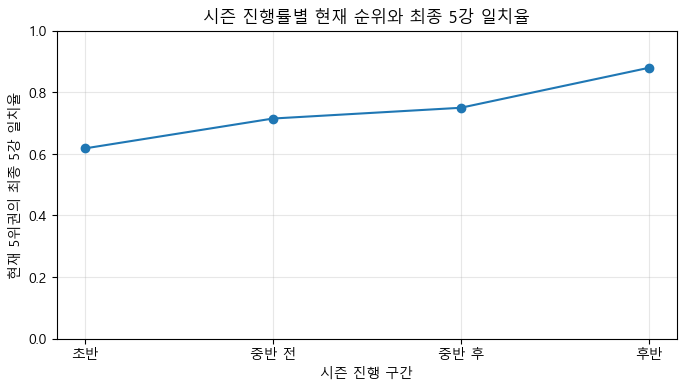

In [157]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(
    phase_result["season_phase"].astype(str),
    phase_result["현재5위권_최종5강_일치율"],
    marker="o"
)
plt.ylim(0, 1)
plt.xlabel("시즌 진행 구간")
plt.ylabel("현재 5위권의 최종 5강 일치율")
plt.title("시즌 진행률별 현재 순위와 최종 5강 일치율")
plt.grid(alpha=0.3)
plt.show()

In [158]:
# 최근 10경기 승률이 높은 팀은 최종 5강에 더 많이 진출했는가?
eda_df["recent10_group"] = pd.cut(
    eda_df["recent10_win_rate"],
    bins=[0, 0.3, 0.5, 0.7, 1.0],
    labels=["0.0~0.3", "0.3~0.5", "0.5~0.7", "0.7~1.0"],
    include_lowest=True
)

recent10_result = eda_df.groupby("recent10_group").agg(
    데이터수=("postseason", "count"),
    최종5강비율=("postseason", "mean"),
    평균현재순위=("rank", "mean"),
    평균승률=("win_rate", "mean")
).reset_index()

recent10_result

,recent10_group,데이터수,최종5강비율,평균현재순위,평균승률
0,0.0~0.3,1035,0.296618,7.484058,0.411939
1,0.3~0.5,2123,0.476684,5.634008,0.492006
2,0.5~0.7,1357,0.613854,4.238025,0.541876
3,0.7~1.0,415,0.754217,2.934940,0.621663


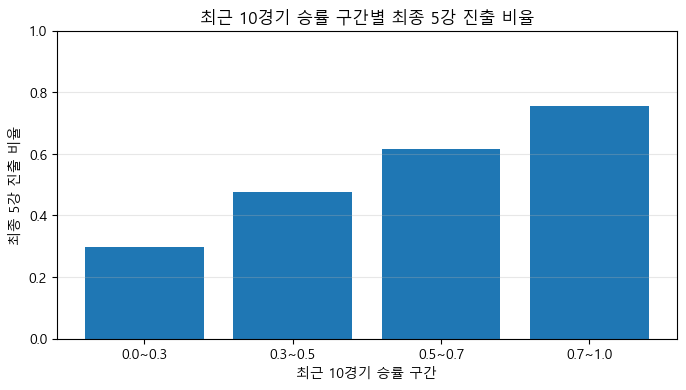

In [159]:
plt.figure(figsize=(8, 4))
plt.bar(
    recent10_result["recent10_group"].astype(str),
    recent10_result["최종5강비율"]
)
plt.ylim(0, 1)
plt.xlabel("최근 10경기 승률 구간")
plt.ylabel("최종 5강 진출 비율")
plt.title("최근 10경기 승률 구간별 최종 5강 진출 비율")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [165]:
# 전년도 OPS/ERA/WHIP이 다음 시즌 포스트시즌 진출 여부와 관련 있는가?

eda_df["prev_hr_group"] = pd.qcut(
    eda_df["prev_team_hr"],
    q=4,
    labels=["홈런 낮음", "홈런 보통하", "홈런 보통상", "홈런 높음"],
    duplicates="drop"
)

hr_result = eda_df.groupby("prev_hr_group").agg(
    데이터수=("postseason", "count"),
    최종5강비율=("postseason", "mean"),
    평균전년도홈런=("prev_team_hr", "mean")
).reset_index()

hr_result

,prev_hr_group,데이터수,최종5강비율,평균전년도홈런
0,홈런 낮음,1312,0.372713,85.036585
1,홈런 보통하,1153,0.572420,102.010408
2,홈런 보통상,1320,0.500000,118.445455
3,홈런 높음,1145,0.572926,157.787773


In [161]:
# ERA 
eda_df["prev_era_group"] = pd.qcut(
    eda_df["prev_team_era"],
    q=4,
    labels=["ERA 낮음", "ERA 보통하", "ERA 보통상", "ERA 높음"],
    duplicates="drop"
)

era_result = eda_df.groupby("prev_era_group").agg(
    데이터수=("postseason", "count"),
    최종5강비율=("postseason", "mean"),
    평균전년도ERA=("prev_team_era", "mean")
).reset_index()

era_result

,prev_era_group,데이터수,최종5강비율,평균전년도ERA
0,ERA 낮음,1324,0.750755,3.726782
1,ERA 보통하,1149,0.283725,4.208825
2,ERA 보통상,1312,0.500000,4.555602
3,ERA 높음,1145,0.427074,5.053502


In [166]:
eda_df["prev_runs_group"] = pd.qcut(
    eda_df["prev_team_runs"],
    q=4,
    labels=["득점 낮음", "득점 보통하", "득점 보통상", "득점 높음"],
    duplicates="drop"
)

runs_result = eda_df.groupby("prev_runs_group").agg(
    데이터수=("postseason", "count"),
    최종5강비율=("postseason", "mean"),
    평균전년도득점=("prev_team_runs", "mean")
).reset_index()

runs_result

,prev_runs_group,데이터수,최종5강비율,평균전년도득점
0,득점 낮음,1320,0.373485,610.930303
1,득점 보통하,1153,0.431049,657.340850
2,득점 보통상,1479,0.666667,732.660581
3,득점 높음,978,0.500000,800.000000


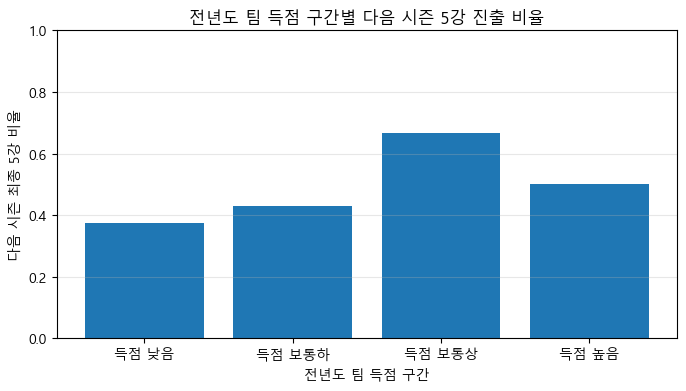

In [167]:
# 전년도 팀 특정 구간별 5강 비율
plt.figure(figsize=(8, 4))
plt.bar(
    runs_result["prev_runs_group"].astype(str),
    runs_result["최종5강비율"]
)
plt.ylim(0, 1)
plt.xlabel("전년도 팀 득점 구간")
plt.ylabel("다음 시즌 최종 5강 비율")
plt.title("전년도 팀 득점 구간별 다음 시즌 5강 진출 비율")
plt.grid(axis="y", alpha=0.3)
plt.show()

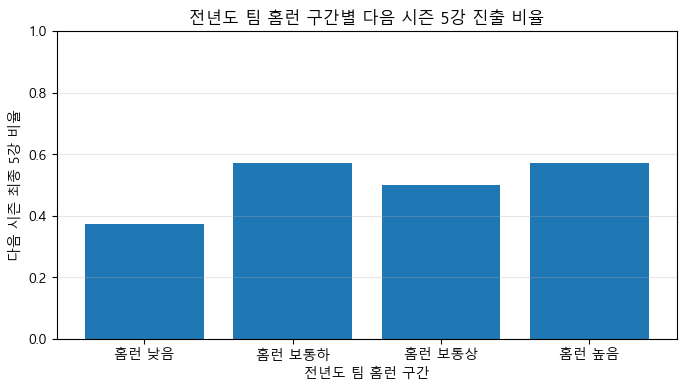

In [168]:
# 홈런으로 보기
eda_df["prev_hr_group"] = pd.qcut(
    eda_df["prev_team_hr"],
    q=4,
    labels=["홈런 낮음", "홈런 보통하", "홈런 보통상", "홈런 높음"],
    duplicates="drop"
)

hr_result = eda_df.groupby("prev_hr_group").agg(
    데이터수=("postseason", "count"),
    최종5강비율=("postseason", "mean"),
    평균전년도홈런=("prev_team_hr", "mean")
).reset_index()

plt.figure(figsize=(8, 4))
plt.bar(
    hr_result["prev_hr_group"].astype(str),
    hr_result["최종5강비율"]
)
plt.ylim(0, 1)
plt.xlabel("전년도 팀 홈런 구간")
plt.ylabel("다음 시즌 최종 5강 비율")
plt.title("전년도 팀 홈런 구간별 다음 시즌 5강 진출 비율")
plt.grid(axis="y", alpha=0.3)
plt.show()

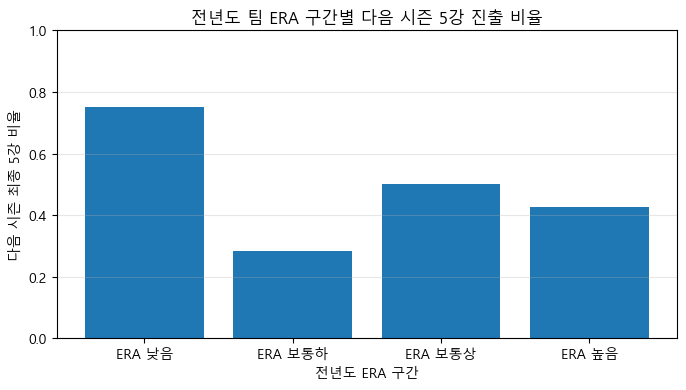

In [163]:
plt.figure(figsize=(8, 4))
plt.bar(
    era_result["prev_era_group"].astype(str),
    era_result["최종5강비율"]
)
plt.ylim(0, 1)
plt.xlabel("전년도 ERA 구간")
plt.ylabel("다음 시즌 최종 5강 비율")
plt.title("전년도 팀 ERA 구간별 다음 시즌 5강 진출 비율")
plt.grid(axis="y", alpha=0.3)
plt.show()

In [169]:
# 모델 학습
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, roc_auc_score

train_df = model_df[model_df["season"].isin([2023, 2024, 2025])].copy()

X = train_df[feature_cols]
y = train_df["postseason"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)
proba = rf.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, pred))
print("F1:", f1_score(y_test, pred))
print("ROC-AUC:", roc_auc_score(y_test, proba))
print(classification_report(y_test, pred))

Accuracy: 1.0
F1: 1.0
ROC-AUC: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       493
           1       1.00      1.00      1.00       493

    accuracy                           1.00       986
   macro avg       1.00      1.00      1.00       986
weighted avg       1.00      1.00      1.00       986



In [170]:
# 변수 중요도
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

importance_df

,feature,importance
18,prev_top5_pitcher_ip_sum,0.114286
15,prev_top5_hitter_rbi_sum,0.092711
12,prev_team_errors,0.087096
2,win_rate,0.084638
17,prev_top5_pitcher_whip_avg,0.079182
0,rank,0.070699
11,prev_team_runs_allowed,0.064164
8,prev_team_era,0.063757
19,prev_top5_pitcher_so_sum,0.061163
16,prev_top5_pitcher_era_avg,0.056137


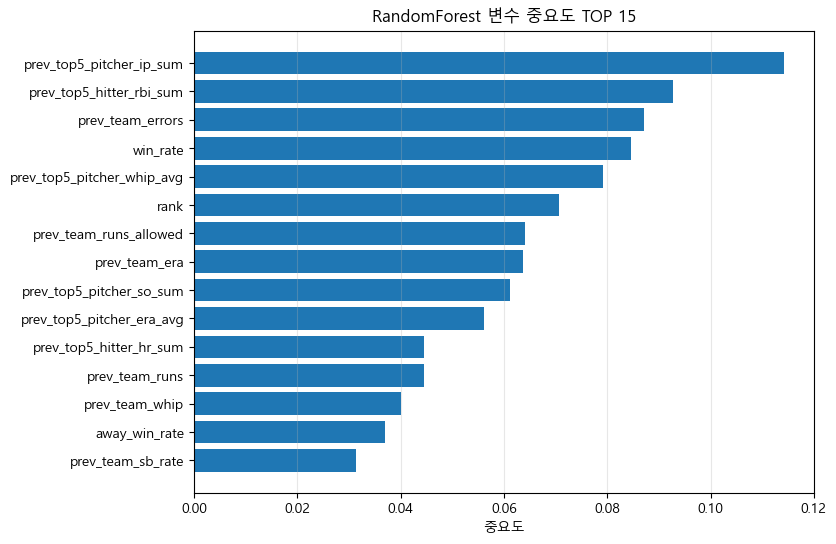

In [171]:
plt.figure(figsize=(8, 6))
plt.barh(
    importance_df["feature"].head(15)[::-1],
    importance_df["importance"].head(15)[::-1]
)
plt.xlabel("중요도")
plt.title("RandomForest 변수 중요도 TOP 15")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [ ]:
#1. 시즌이 진행될수록 현재 5위권과 최종 5강의 일치율이 높아지는지 확인 가능

#2. 최근 10경기 승률이 높은 팀이 최종 5강에 더 자주 진입하는지 확인 가능

#3. 전년도 OPS, ERA, WHIP 등 팀 전력 지표가 다음 시즌 postseason 여부와 연결되는지 확인 가능